### 1. Load Data


In [73]:
import sys
import subprocess
import warnings
warnings.filterwarnings("ignore")

try:
    import mlxtend
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "mlxtend"])

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

In [74]:
basket = pd.read_csv("../Data/basket.csv",index_col =0)

In [75]:
basket.head()

,Action Figure BlueViolet 416,Action Figure BlueViolet 644,Action Figure CornflowerBlue 738,Action Figure DarkMagenta 470,Action Figure DarkOliveGreen 231,Action Figure DarkRed 648,Action Figure DarkTurquoise 818,Action Figure DimGray 345,Action Figure DimGray 373,Action Figure Gainsboro 419,...,Yoga Mat PaleGoldenRod 666,Yoga Mat RoyalBlue 756,Yoga Mat Salmon 216,Yoga Mat Sienna 226,Yoga Mat Sienna 447,Yoga Mat SlateGray 624,Yoga Mat SlateGray 628,Yoga Mat SlateGray 857,Yoga Mat Tan 453,Yoga Mat Tan 530
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### 2. Apply FP-Growth


In [76]:
frequent_items = fpgrowth(
    basket[basket.sum(axis=1) >= 2],
    min_support=0.0001,
    use_colnames=True,
    max_len=2
)

frequent_items = frequent_items.sort_values(by="support", ascending=False)

frequent_items.head(20)

,support,itemsets
344,0.006332,(Lipstick LightBlue 766)
149,0.005668,(Conditioner CornflowerBlue 855)
6,0.005307,(Lipstick RosyBrown 771)
533,0.005126,(Moisturizer IndianRed 706)
548,0.005126,(E-book PeachPuff 118)
109,0.005065,(Air Fryer MediumTurquoise 924)
76,0.005005,(Serum DarkCyan 813)
196,0.004945,(Lipstick Thistle 546)
379,0.004945,(Paperback GoldenRod 900)
66,0.004885,(Paperback MediumSpringGreen 697)


### 3. Frequent Product Pairs

In [77]:
frequent_pairs = frequent_items[frequent_items["itemsets"].apply(lambda x: len(x) >= 2)]

frequent_pairs.head(20)

,support,itemsets
1683,0.000302,"(Hardcover LightBlue 484, Lipstick LightBlue 766)"
2997,0.000241,"(Puzzle DarkCyan 484, Action Figure PeachPuff ..."
1404,0.000241,"(Building Blocks DarkSeaGreen 909, Board Game ..."
1660,0.000241,"(Moisturizer IndianRed 706, Serum DarkSeaGreen..."
1252,0.000241,"(Water Bottle PapayaWhip 550, Cycling Helmet M..."
1232,0.000241,"(Puzzle PowderBlue 921, Doll LightCyan 982)"
1540,0.000241,"(Hardcover LightGreen 573, Hardcover LightSalm..."
2346,0.000241,"(E-book SpringGreen 159, E-book LightCoral 987)"
2481,0.000241,"(Paperback GoldenRod 900, Hardcover BlueViolet..."
3113,0.000181,"(Yoga Mat LightSteelBlue 936, Water Bottle Sea..."


### 4. Generate Association Rules


In [78]:
rules = association_rules(
    frequent_items,
    metric="lift",
    min_threshold=1
)

rules = rules.sort_values(by="lift", ascending=False)

rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
353,(Mouse Chartreuse 292),(Monitor DarkKhaki 939),0.002653,0.000241,0.000121,0.045455,188.443182,1.0,0.000120,1.047366,0.997340,0.043478,0.045224,0.272727
352,(Monitor DarkKhaki 939),(Mouse Chartreuse 292),0.000241,0.002653,0.000121,0.500000,188.443182,1.0,0.000120,1.994693,0.994933,0.043478,0.498670,0.272727
4160,(SSD Lime 581),(Mouse MediumSpringGreen 253),0.002774,0.000302,0.000121,0.043478,144.200000,1.0,0.000120,1.045139,0.995828,0.040816,0.043190,0.221739
4161,(Mouse MediumSpringGreen 253),(SSD Lime 581),0.000302,0.002774,0.000121,0.400000,144.200000,1.0,0.000120,1.662043,0.993365,0.040816,0.398331,0.221739
4138,(Speaker DarkRed 848),(Mouse FireBrick 843),0.000302,0.002774,0.000121,0.400000,144.200000,1.0,0.000120,1.662043,0.993365,0.040816,0.398331,0.221739
4139,(Mouse FireBrick 843),(Speaker DarkRed 848),0.002774,0.000302,0.000121,0.043478,144.200000,1.0,0.000120,1.045139,0.995828,0.040816,0.043190,0.221739
3627,(Water Bottle DarkSlateBlue 296),(Dumbbell DarkTurquoise 262),0.000663,0.002352,0.000121,0.181818,77.310023,1.0,0.000119,1.219348,0.987720,0.041667,0.179889,0.116550
3626,(Dumbbell DarkTurquoise 262),(Water Bottle DarkSlateBlue 296),0.002352,0.000663,0.000121,0.051282,77.310023,1.0,0.000119,1.053355,0.989392,0.041667,0.050652,0.116550
416,(Jacket SlateBlue 368),(Jeans AliceBlue 734),0.002714,0.000603,0.000121,0.044444,73.702222,1.0,0.000119,1.045881,0.989116,0.037736,0.043868,0.122222
417,(Jeans AliceBlue 734),(Jacket SlateBlue 368),0.000603,0.002714,0.000121,0.200000,73.702222,1.0,0.000119,1.246608,0.987027,0.037736,0.197823,0.122222


### 5. Clean Final Rules Table

In [ ]:
rules_display = rules.copy()

rules_display["antecedents"] = rules_display["antecedents"].apply(lambda x: ", ".join(list(x)))
rules_display["consequents"] = rules_display["consequents"].apply(lambda x: ", ".join(list(x)))

final_rules = rules_display[["antecedents", "consequents", "support", "confidence", "lift"]]

final_rules.head(20)
final_rules.to_csv("../Data/Final_rules.csv")

### 6. Recommendation Function

In [80]:
def recommend_products(product_name, rules_table=final_rules, top_n=5):
    recommendations = rules_table[rules_table["antecedents"] == product_name]
    recommendations = recommendations.sort_values(by="lift", ascending=False)
    return recommendations[["antecedents", "consequents", "confidence", "lift"]].head(top_n)

example_product = final_rules.iloc[0]["antecedents"]
print("Example product:", example_product)
recommend_products(example_product)

Example product: Mouse Chartreuse 292


,antecedents,consequents,confidence,lift
353,Mouse Chartreuse 292,Monitor DarkKhaki 939,0.045455,188.443182
2960,Mouse Chartreuse 292,Conditioner Magenta 557,0.045455,19.327506


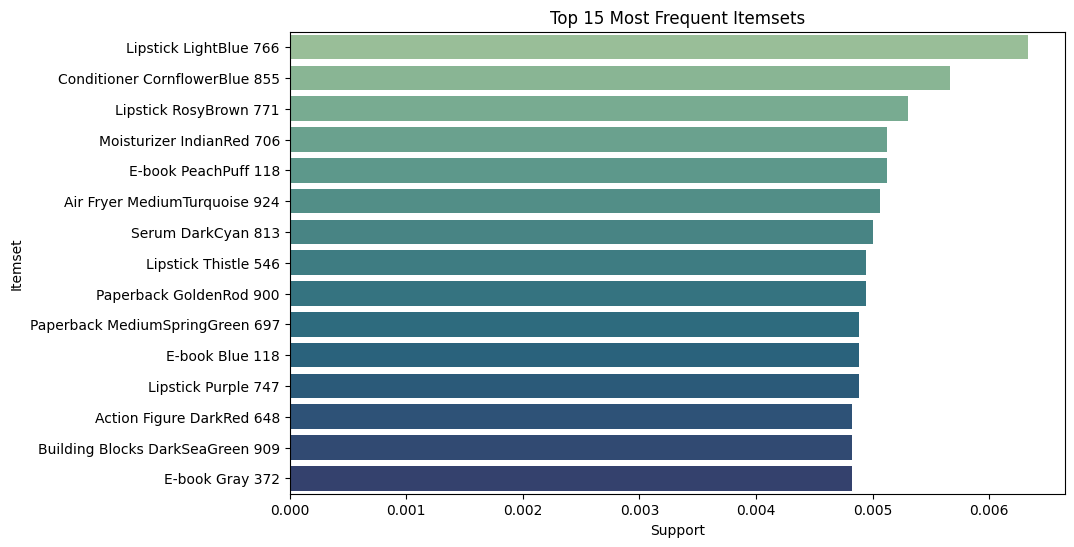

In [ ]:
top_itemsets = frequent_items.sort_values('support', ascending=False).head(15)

top_itemsets['item_str'] = top_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(10, 6))
sns.barplot(x='support', y='item_str', data=top_itemsets, palette="crest")
plt.title("Top 15 Most Frequent Itemsets")
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.show()

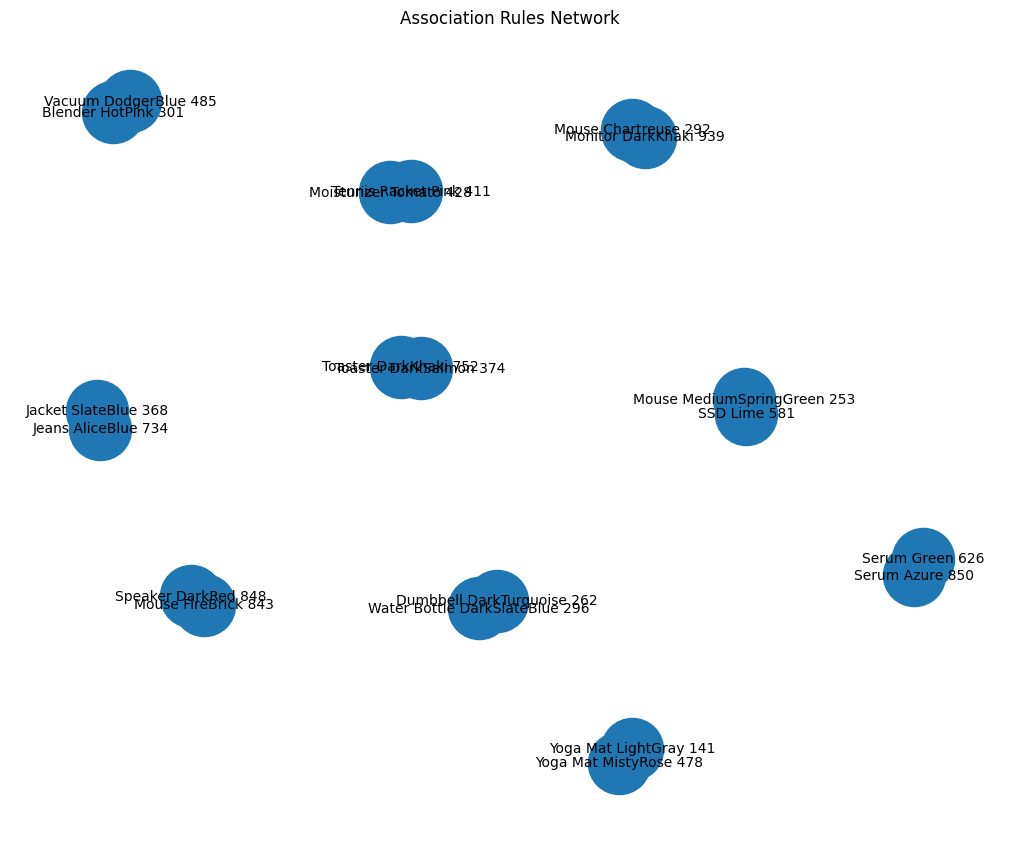

In [91]:
import networkx as nx

G = nx.DiGraph()

for _, row in rules.head(20).iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c, weight=row['lift'])

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000, font_size=10)
plt.title("Association Rules Network")
plt.show()

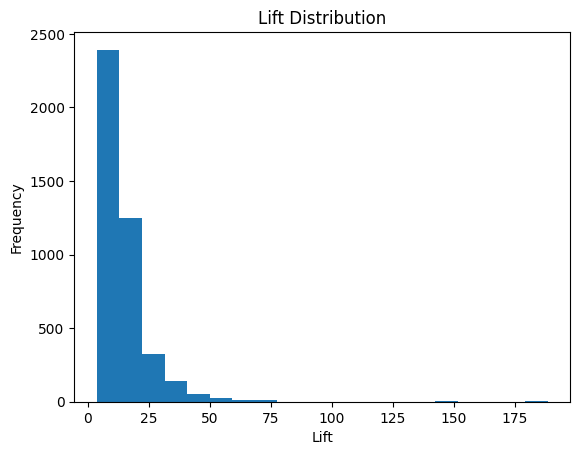

In [92]:
plt.hist(rules['lift'], bins=20)
plt.title("Lift Distribution")
plt.xlabel("Lift")
plt.ylabel("Frequency")
plt.show()

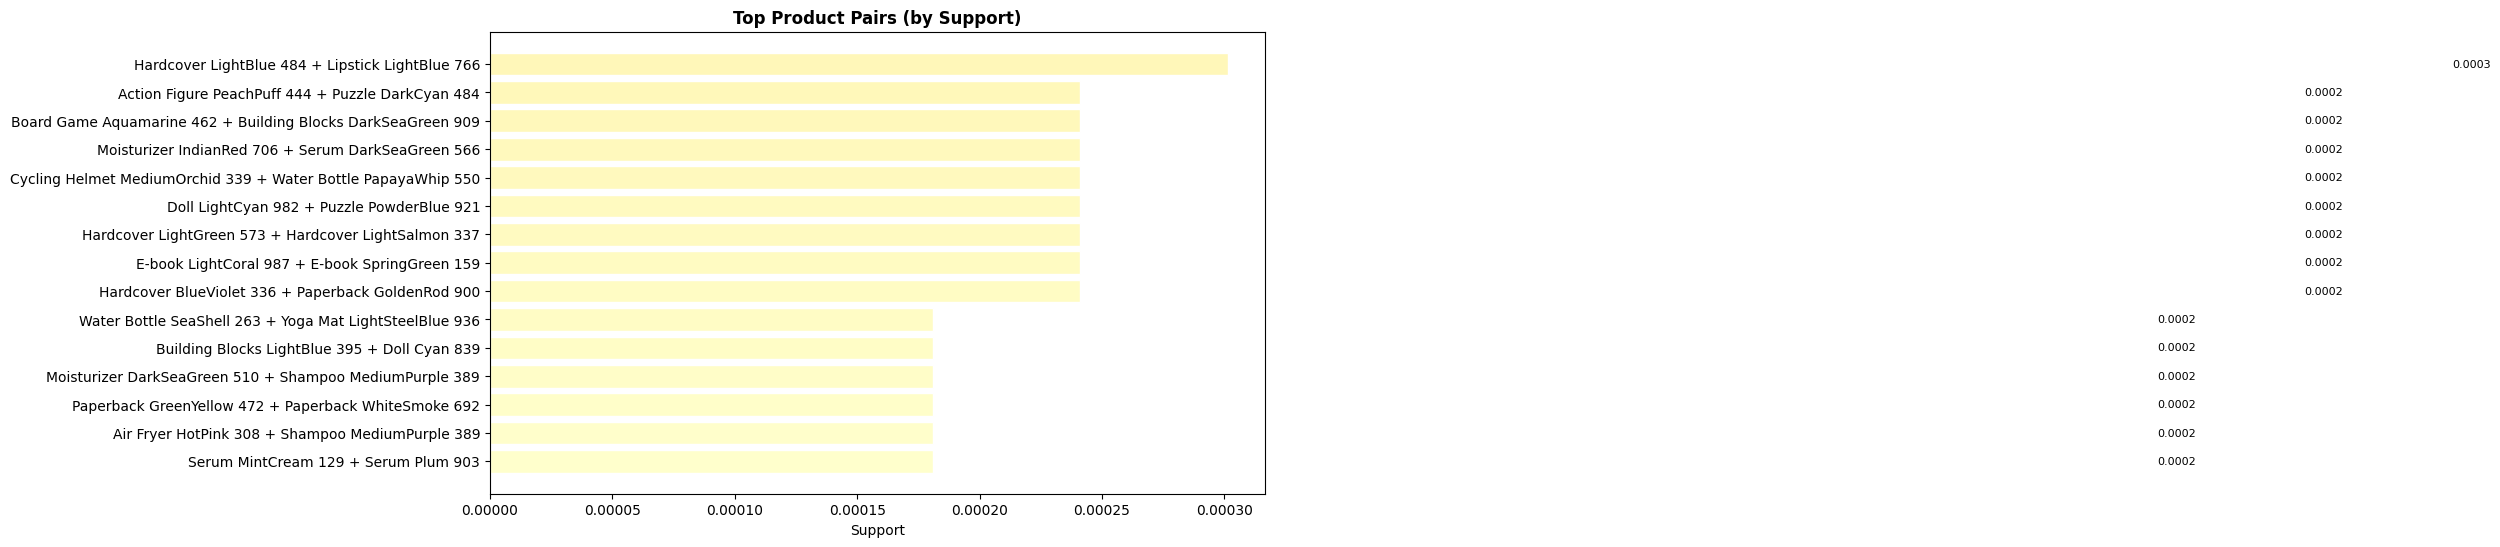

In [94]:
pairs_display = frequent_pairs.copy()
pairs_display['pair'] = pairs_display['itemsets'].apply(lambda x: ' + '.join(sorted(x)))

pairs_display = pairs_display.sort_values('support', ascending=False).head(15)

plt.figure(figsize=(10,6))
bars = plt.barh(pairs_display['pair'][::-1], pairs_display['support'][::-1],
                color=plt.cm.YlOrRd(range(len(pairs_display))), edgecolor='white')

plt.title('Top Product Pairs (by Support)', fontweight='bold')
plt.xlabel('Support')

for bar, v in zip(bars, pairs_display['support'][::-1]):
    plt.text(bar.get_width()+0.0005, bar.get_y()+bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

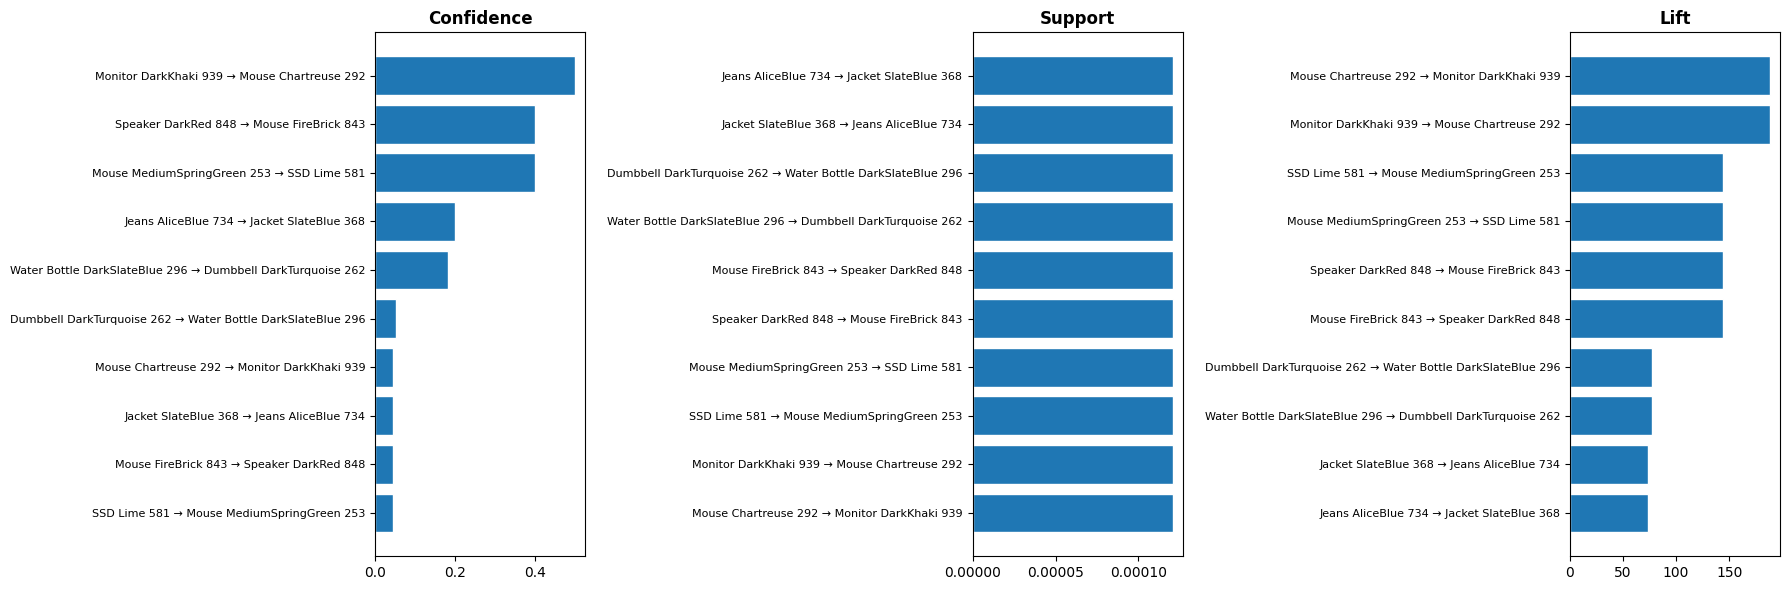

In [95]:
top_rules = final_rules.head(10).copy()
top_rules['rule'] = top_rules['antecedents'] + ' → ' + top_rules['consequents']

fig, axes = plt.subplots(1, 3, figsize=(18,6))

for ax, metric in zip(axes, ['confidence','support','lift']):
    sr = top_rules.sort_values(metric)
    bars = ax.barh(sr['rule'], sr[metric], edgecolor='white')
    ax.set_title(metric.capitalize(), fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()